# Linear Regression — Step by Step

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

plt.rcParams['figure.figsize'] = (7, 4)


## 2. Load data

In [2]:
df = pd.read_csv('data/Salary_Data.csv')
df.head()


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## 3. EDA — check linearity

Do this **before** fitting. Low `corr()` + a curved scatter plot means
non-linear — use Polynomial Regression instead.

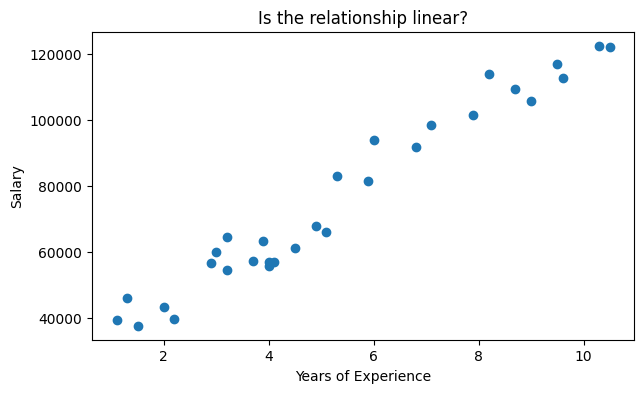

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [3]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Is the relationship linear?')
plt.show()

df.corr()


## 4. Define X and y

In [4]:
x = df[['YearsExperience']]   # 2D — features
y = df['Salary']              # 1D — target


## 5. Train/test split

In [5]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)
xtrain.shape, xtest.shape


((24, 1), (6, 1))

## 6. Scaling (optional here)

Not required to fit correctly — only needed for regularized models
(Ridge/Lasso) or to compare coefficients fairly. Skipped below; shown for
reference:

In [6]:
# scaler = StandardScaler()
# xtrain_scaled = scaler.fit_transform(xtrain)   # fit_transform on TRAIN
# xtest_scaled = scaler.transform(xtest)          # transform only on TEST


## 7. Fit the model

In [7]:
model = LinearRegression()
model.fit(xtrain, ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 8. Inspect coefficients

In [8]:
print("Slope (coef):", model.coef_)
print("Intercept   :", model.intercept_)
# y = coef * YearsExperience + intercept


Slope (coef): [9423.81532303]
Intercept   : 25321.583011776813


## 9. Predict

In [9]:
ypred_train = model.predict(xtrain)
ypred_test = model.predict(xtest)
ypred_test[:5]


array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548])

## 10. Evaluate

| Metric | Meaning |
|---|---|
| R² | % of variance in target explained (closer to 1 = better) |
| MAE | Average absolute error, same units as target |
| RMSE | Like MAE but penalizes large errors more |

Check **both** train and test scores — a big gap means overfitting.

In [10]:
print("Train R2  :", r2_score(ytrain, ypred_train))
print("Test R2   :", r2_score(ytest, ypred_test))
print("Test MAE  :", mean_absolute_error(ytest, ypred_test))
print("Test RMSE :", root_mean_squared_error(ytest, ypred_test))


Train R2  : 0.9645401573418146
Test R2   : 0.9024461774180497
Test MAE  : 6286.453830757749
Test RMSE : 7059.04362190151


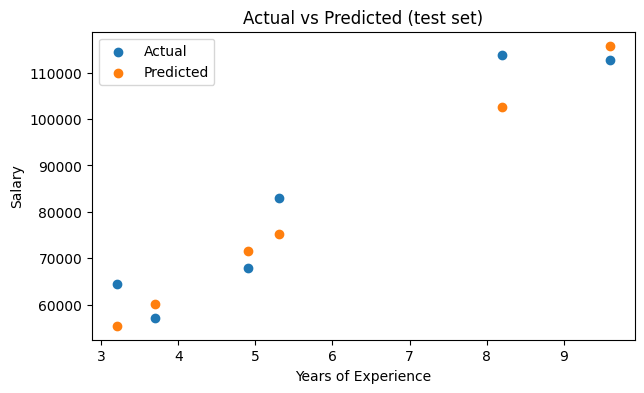

In [11]:
plt.scatter(xtest, ytest, label='Actual')
plt.scatter(xtest, ypred_test, label='Predicted')
plt.xlabel('Years of Experience'); plt.ylabel('Salary')
plt.legend()
plt.title('Actual vs Predicted (test set)')
plt.show()


## 11. Multiple Linear Regression

Same steps, just more than one feature — no change to the process.

In [12]:
ads = pd.read_csv('data/Advertising.csv')
ads.columns = [c.strip() for c in ads.columns]
if ads.columns[0] == '':
    ads = ads.drop(columns=ads.columns[0])
ads.head()


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [13]:
ads[['TV', 'Radio', 'Newspaper']].corrwith(ads['Sales'])


TV           0.782224
Radio        0.576223
Newspaper    0.228299
dtype: float64

In [14]:
x2 = ads[['TV', 'Radio', 'Newspaper']]
y2 = ads['Sales']
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(x2, y2, train_size=0.8, random_state=42)

mlr_model = LinearRegression()
mlr_model.fit(xtrain2, ytrain2)

print("Coefficients:", dict(zip(x2.columns, mlr_model.coef_)))
print("Intercept   :", mlr_model.intercept_)


Coefficients: {'TV': np.float64(0.044729517468716326), 'Radio': np.float64(0.1891950542343766), 'Newspaper': np.float64(0.0027611143413672056)}
Intercept   : 2.9790673381226256


In [15]:
ypred_test2 = mlr_model.predict(xtest2)
print("Test R2  :", r2_score(ytest2, ypred_test2))
print("Test MAE :", mean_absolute_error(ytest2, ypred_test2))
print("Test RMSE:", root_mean_squared_error(ytest2, ypred_test2))


Test R2  : 0.899438024100912
Test MAE : 1.4607567168117606
Test RMSE: 1.7815996615334502
